# 各ピーク有意度計算・ピーク除外再フィット
## 
- 全てのピークの有意度を計算する。(p-value, sigma)
- ピーク領域を除いて再フィットし、再度ピーク検出を行い、ピーク有意度を再計算する。(p-value2, sigma2)
- 再度ピーク検出においてピーク検出されたSEDの出力をする。

## 更新履歴
- 再度ピーク検出のSED出力　
- ピーク有意度比較散布図追加　924f2d1ad490c90c403cd7824f653ed496c50b56




## 主要部分

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack
from astropy.modeling.powerlaws import LogParabola1D
from astropy.modeling import models, fitting
from astropy import units as u
from scipy.optimize import curve_fit
from scipy.stats import chi2, norm


### ピーク検出・有意度計算

In [11]:
################################################
### # Peak significance calculation - not used
### This must be used with the listing of all the data points
### of consecutive positive deviations, 
### which can be more than three
################################################
def calc_peak_significance(ri):
#     '''
#     fit (array) values for the fit
#     x,y,yerr (arrays) data
#     N total number of points
#     n_free number of parameters we are fitting
#     '''
#     return 1.0/(N-n_free)*sum(((fit - y)/yerr)**2)
# import numpy as np
# from scipy.stats import chi2, norm
# # only those residuals that form the (at least) 3 consecutive positive deviations
# ri = np.array([1, 2, 3.])

# # Chi-square of those residuals
  chi2_value = np.sum(ri**2)

# # p-value for chi-square with m degrees of freedom - m = len(ri) - this is the probability of obtaining a test statistic at least as high as chi2_value
  p_val = 1 - chi2.cdf(chi2_value, df=len(ri))

# # p-value to Gaussian-equivalent one-sided significance
  sigma_equiv = norm.ppf(1 - p_val)

  return p_val, sigma_equiv


###################
# Peak detection
###################
def get_consecutive_bins_for_multi_peaks(s,nconsecutive = 3 ):
  # from s, find all the sets of consecutive bins that have values > 1.0 for at least nconsecutive bins
  # return the list of (peakinitbin, peaklength, significance)s
  peakinitbins=[]
  peaklengths=[]
  significances=[]
  peakinitbin = -1
  for i in range(0,len(s)-nconsecutive+1):  
    if np.all(s[i:i+nconsecutive] > 1.0):
      if peakinitbin < 0:
        peakinitbin = i
      if i + nconsecutive == len(s):
        peakinitbins.append(peakinitbin)
        peaklengths.append(i + nconsecutive - peakinitbin)
        significances.append(calc_peak_significance(s[peakinitbin:i+nconsecutive]))
        return   peakinitbins,peaklengths,significances
    else:
      if peakinitbin >= 0:
        peakinitbins.append(peakinitbin)
        peaklengths.append(i + nconsecutive -1 - peakinitbin)
        significances.append(calc_peak_significance(s[peakinitbin:i+nconsecutive-1]))
        peakinitbin = -1
  return   peakinitbins,peaklengths,significances



### ピーク領域除外フィット結果プロット

In [12]:
def plotSED_peakExcludedFit_erg_GeV(x, y, yerr, fitted_line,  fitted_line2, peakinitbins, peaklengths, fitexcludeinitbin,fitexcludelength, residuals,reduced_chi_squared, obsdate, idx, sourcename='',sourcenameheader=''):
  
  y_scalefactor= (y.to(u.Unit("erg cm-2 s-1")).value/y.value)[0]
  model_y  = fitted_line(x) * y_scalefactor
  model2_y = fitted_line2(x) * y_scalefactor
  
  x = x.to(u.GeV).value  
  y = y.to(u.Unit("erg cm-2 s-1")).value
  yerr = yerr.to(u.Unit("erg cm-2 s-1")).value
  
   # Plot the SED with the fitted line, with the residual plot at the bottom
  fig = plt.figure(figsize=(10, 6))
  frame1=fig.add_axes((.1,.3,.8,.6))
  plt.errorbar(x, y, yerr=yerr, marker='o', linestyle='', label='Data')
  plt.plot(x, model_y, '-', color='gray',label='Fitted Line')
  if (fitexcludeinitbin>0):
    plt.plot(x[0:fitexcludeinitbin], model2_y[0:fitexcludeinitbin], '-', color='orange',label='Refitted Line')
  plt.plot(x[fitexcludeinitbin-1: fitexcludeinitbin+fitexcludelength+1], model2_y[fitexcludeinitbin-1: fitexcludeinitbin+fitexcludelength+1], '--', color='orange')
  if (fitexcludeinitbin + fitexcludelength +1 < len(x)):
    plt.plot(x[fitexcludeinitbin + fitexcludelength :], model2_y[fitexcludeinitbin + fitexcludelength:], '-', color='orange')

  for peakbininit, peaklength in zip(peakinitbins, peaklengths):
    plt.plot(x[peakbininit:peakbininit+peaklength],
              y[peakbininit:peakbininit+peaklength], label='Peak Region', marker='x', linestyle='-',color='red')
  # plt.title(f"Observation {idx}: MJD {int(obsdate)} "+ r"$\chi^2$/ndf=" +f" {reduced_chi_squared:.2f}")
  # plt.title(f"GB6J1040+0617 : MJD {int(obsdate)} "+ r"$\chi^2$/ndf=" +f" {reduced_chi_squared:.2f}")
  plt.title(f"{sourcename} : MJD {round(obsdate,3)} "+ r"$\chi^2$/ndf=" +f" {reduced_chi_squared:.2f}")
  plt.xlabel('Energy [GeV]')
  plt.ylabel(r"E$^2d\phi/d$E [erg/cm$^{-2}$ s$^{-1}$]")
  plt.xscale('log')
  plt.yscale('log')
  # plt.xlim(100, 3e3)
  # plt.ylim(1e-2, 2) # for GB6J1040+0617
  # plt.ylim(1e-4, 2e-3)

  plt.legend()

  frame2=fig.add_axes((.1,.1,.8,.2))  
  plt.plot(x, residuals, '.', label='Residuals')
  plt.axhline(0, color='red', linestyle='--', label='Zero Line')
  plt.xlabel('Energy [GeV]')
  plt.ylabel('Residuals')
  plt.xscale('log')
  plt.legend()
  plt.tight_layout()

  # plt.xlim(100, 3e3)
  # plt.show()
  plt.savefig(f"figures/{sourcenameheader}{sourcename}_sedwithpeak_{idx}_refit_wopeakloc{fitexcludeinitbin}.png", dpi=300, bbox_inches='tight')

### 主体関数

In [45]:

nbinsmin=9

###################
# Utility functions
###################
def gaussian(x, amplitude, mu, sigma):
    # return (1.0 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mu) / sigma) ** 2) : Normal distribution
    return amplitude * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

def calc_reduced_chi_square(fit, x, y, yerr, N, n_free):
    '''
    fit (array) values for the fit
    x,y,yerr (arrays) data
    N total number of points
    n_free number of parameters we are fitting
    '''
    return 1.0/(N-n_free)*sum(((fit - y)/yerr)**2)

###################
# Main function
###################
def eval_spectra(filepath,suffix='',sourcename=''): #'data/3C454.3_allsed_14d_min11.ecsv'
  nconsecutive = 3
  sourcenameheader = ''
  if suffix != '':
    sourcenameheader = suffix + '_'

  if sourcename == '':
    sourcename = filepath.split('_')[0]
    sourcename = sourcename.replace('data/', '')
  # logpar_init = LogParabola1D(amplitude=1,x_0=10,alpha=1,beta=1)
  logpar_init = LogParabola1D(
    amplitude = 0.000016494113774149846,
    x_0 = 9.482855296727278,
    alpha = -0.5677548858840729,
    beta=0)
    # beta = 0.1071613245072173)

  ### initialize a linear fitter ###
  # fit = fitting.TRFLSQFitter()
  fit = fitting.DogBoxLSQFitter()

  ### Read the data ###
  t0 = Table.read(filepath)
  nonzero_mask = (t0['e2dnde'] > t0['e2dnde_err'])
  t = t0[nonzero_mask]

  ### MJDごとに処理 ###
  obsdates=np.unique(t['tstart'].data).tolist()
  n_detected_peaks = 0
  array_nbins = []
  array_chisq = []
  t_peakstat = Table(names = ['day#','peak length','SED length','p-value','sigma','p-value2','sigma2'], dtype = ['i2','i2','i2','f4' ,'f4','f4' ,'f4'])
  for idx, obsdate in enumerate(obsdates):
    # print(idx, ': obsdate',obsdate)
    mask = (t['tstart']==obsdate)
    x = t[mask]['e_ref']
    y = t[mask]['e2dnde']
    yerr = t[mask]['e2dnde_err']
    nbins = len(x)
    if nbins < nbinsmin:
        print('nbins < nbinsmin:',nbins)
        continue
    array_nbins.append(nbins)
    
    ### fit the data with the fitter ###
    # logpar_init.amplitude.value=x[1]*1.0e-8
    fitted_line = fit(logpar_init, x,y,weights=1.0/yerr, maxiter=200)
    residuals = (y-fitted_line(x))/yerr
    # print(fit.fit_info)
    # residuals = (fitted_line(x)-y)/yerr # negative:dip finding
    reduced_chi_squared = calc_reduced_chi_square(fitted_line(x), x, y, yerr, len(x), 4)
    array_chisq.append(reduced_chi_squared)
    if reduced_chi_squared > 4.0:
      # refit with another beta 
      logpar_init.beta.value = 0.1
      fitted_line = fit(logpar_init, x,y,weights=1.0/yerr, maxiter=200)
      residuals = (y-fitted_line(x))/yerr
      reduced_chi_squared = calc_reduced_chi_square(fitted_line(x), x, y, yerr, len(x), 4)  
      
    
    peakinitbins,peaklengths,significances = get_consecutive_bins_for_multi_peaks(residuals,nconsecutive)
    if len(peakinitbins) > 0:
      print('get_consecutive_bins_for_multi_peaks')
      n_detected_peaks += 1
      print('***** Detected ', len(peakinitbins), ' peaks in the SED for ', sourcename, ' at MJD ', obsdate)
      for i_peak in range(len(peakinitbins)):
        print('  Peak #', i_peak+1, ': Found peak at bin:',peakinitbins[i_peak], 'length ', peaklengths[i_peak], 'in total length of ', len(residuals), 'p-value, sigma:', significances[i_peak])
        
        # refit without the peak region and see the significance of the peak again
        mask_nopk = np.ones(len(x), dtype=bool)
        mask_nopk[peakinitbins[i_peak]:peakinitbins[i_peak]+peaklengths[i_peak]] = False
        # if np.sum(mask_nopk) < nbinsmin:
        #   print('  Too few points to refit without the peak region')
        #   continue
        fitted_line2 = fit(logpar_init, x[mask_nopk],y[mask_nopk],weights=1.0/yerr[mask_nopk], maxiter=200)
        residuals2 = (y-fitted_line2(x))/yerr
        peakinitbins2,peaklengths2,significances2 = get_consecutive_bins_for_multi_peaks(residuals2,nconsecutive)
        i_peak2_save = -1
        if len(peakinitbins2) > 0:
          print('  After refitting without the peak region, Detected ', len(peakinitbins2), ' peaks in the SED for ', sourcename, ' at MJD ', obsdate)
          for i_peak2 in range(len(peakinitbins2)):
            print('    Peak #', i_peak2+1, ': Found peak at bin:',peakinitbins2[i_peak2], 'length ', peaklengths2[i_peak2], 'in total length of ', len(residuals2), 'p-value, sigma:', significances2[i_peak2])
            if x[peakinitbins[i_peak]]*0.5 < x[peakinitbins2[i_peak2]] or x[peakinitbins[i_peak]]*1.5 > x[peakinitbins2[i_peak2]]  :
              i_peak2_save = i_peak2
          # plotSED_peakExcludedFit_erg_GeV(x, y , yerr, fitted_line, fitted_line2, peakinitbins2, peaklengths2,
          #                                 peakinitbins[i_peak], peaklengths[i_peak], residuals2, reduced_chi_squared, obsdate, idx,sourcename,sourcenameheader)
# def plotSED_peakExcludedFit_erg_GeV(x, y, yerr, fitted_line, peakinitbins, peaklengths, 
                                    # fitexcludeinitbin,fitexcludelength, residuals,reduced_chi_squared, obsdate, idx, sourcename='',sourcenameheader=''):
        else:
          print('  After refitting without the peak region, No significant peak found')
        t_peakstat.add_row([idx, peaklengths[i_peak], len(residuals), significances[i_peak][0], significances[i_peak][1], significances2[i_peak2_save][0] if len(significances2) > 0 else -1, significances2[i_peak2_save][1] if len(significances2) > 0 else -1])

  print(t_peakstat)
  return t_peakstat

### 実行テスト

get_consecutive_bins_for_multi_peaks
***** Detected  1  peaks in the SED for  3C454.3  at MJD  56824.65603222185
  Peak # 1 : Found peak at bin: 9 length  3 in total length of  21 p-value, sigma: (0.10888681382133736, 1.2324698360558637)
  After refitting without the peak region, Detected  1  peaks in the SED for  3C454.3  at MJD  56824.65603222185
    Peak # 1 : Found peak at bin: 9 length  3 in total length of  21 p-value, sigma: (0.009424379663663829, 2.348508690719464)


/var/folders/xw/2d80lcgs4q70yxd586wjb4sh0000gn/T/ipykernel_94783/416835575.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


get_consecutive_bins_for_multi_peaks
***** Detected  1  peaks in the SED for  3C454.3  at MJD  57426.65603222185
  Peak # 1 : Found peak at bin: 9 length  3 in total length of  14 p-value, sigma: (0.13022345354587705, 1.1253354640736548)
  After refitting without the peak region, Detected  1  peaks in the SED for  3C454.3  at MJD  57426.65603222185
    Peak # 1 : Found peak at bin: 9 length  3 in total length of  14 p-value, sigma: (0.007144940031461378, 2.449892676401162)
peak length SED length   p-value     sigma    p-value2    sigma2 
----------- ---------- ----------- --------- ---------- ---------
          3         21 0.108886816 1.2324698 0.00942438 2.3485086
          3         14  0.13022345 1.1253355 0.00714494 2.4498928


peak length,SED length,p-value,sigma,p-value2,sigma2
int16,int16,float32,float32,float32,float32
3,21,0.108886816,1.2324698,0.00942438,2.3485086
3,14,0.13022345,1.1253355,0.00714494,2.4498928


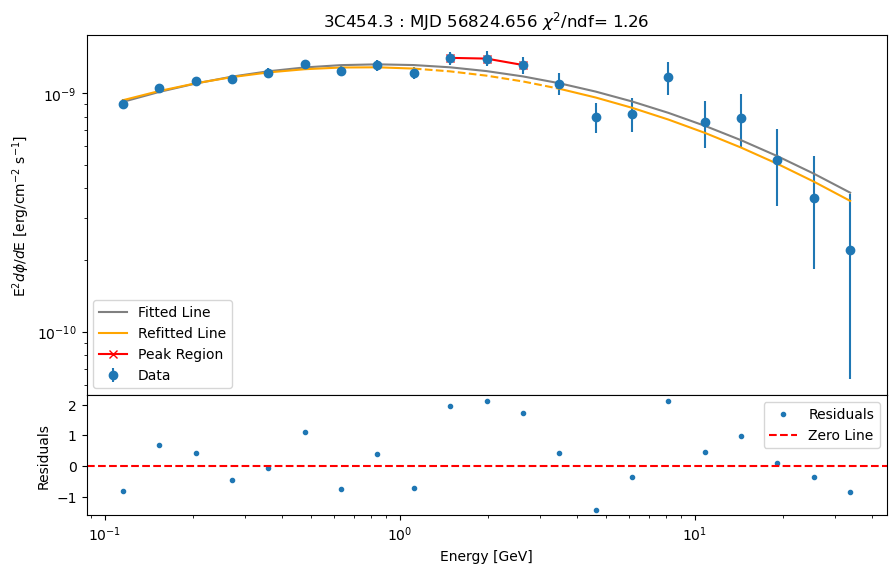

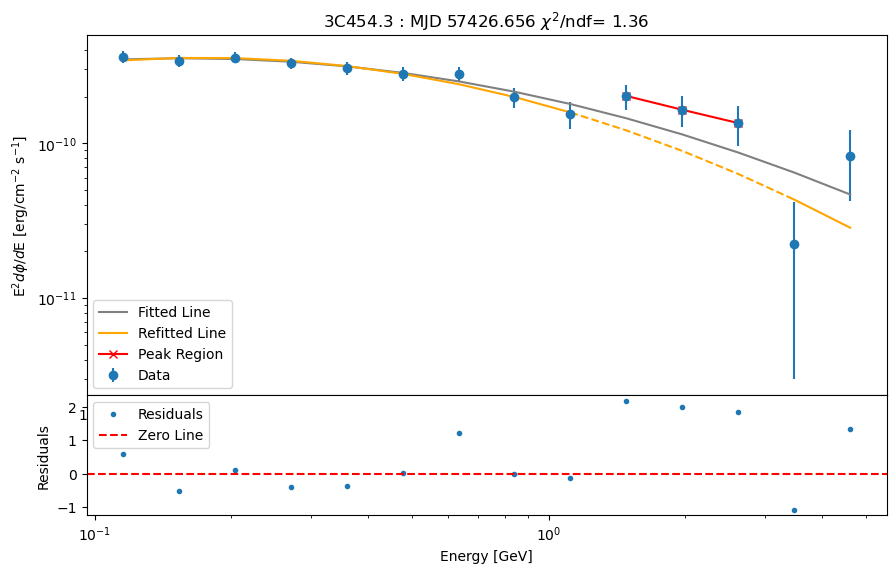

In [16]:
eval_spectra('data/3C454.3_allsed_14d_min11.ecsv')  # 2pos, 0neg/264
# eval_spectra('data/3C454.3_allsed_1d_min11.ecsv')  # 8pos
# eval_spectra('data/Mrk421_allsed_14d_min11.ecsv') 
# eval_spectra('data/BLLac_allsed_14d_min11.ecsv') # 1 two-peak SED
# eval_spectra('data/BLLac_allsed_1d_min11.ecsv') 
# eval_spectra('data/3C279_allsed_14d_min11.ecsv') 
# eval_spectra('data/3C279_allsed_1d_min11.ecsv') 
# eval_spectra('data/CTA102_allsed_14d_min11.ecsv') 
# eval_spectra('data/CTA102_allsed_1d_min11.ecsv')
# eval_spectra('data/PKS0426-380_allsed_14d_min11.ecsv') # 5 pos, 1 4-bin peak
# eval_spectra('data/PKS2155-304_allsed_14d_min11.ecsv')
# eval_spectra('data/PKS1424-41_allsed_14d_min11.ecsv')



## 全データ解析
### 天体名対応辞書作成
### - 辞書定義(4FGLカタログ準拠)

In [46]:
from astropy.io import fits
import numpy as np

def get_dict_sourcenames():
  num_sources = 2300
  hdu=fits.open('/Users/kazuma/Workspace/Torun/Fermi/catalog/gll_psc_v35.fit')
  significances = hdu[1].data['Signif_Avg']
  sources = hdu[1].data['Source_Name']
  sources1 = hdu[1].data['ASSOC1']
  sources2 = hdu[1].data['ASSOC2']
  sources_cls=hdu[1].data['CLASS1']
  #Convert source classes to normal array without empty spaces
  source_classes = np.array([entry.strip() for entry in hdu[1].data['CLASS1']])
  #Filter by source class:
  source_classes_selected = np.array(["bll","fsrq","BLL","FSRQ"],dtype='<U5') #see table 5 in https://arxiv.org/pdf/2201.11184
  element_map = np.isin(source_classes, source_classes_selected)
  significances_blazars= significances[element_map]
  sources_blazars = sources[element_map]
  sources_blazars1 = sources1[element_map]
  sources_blazars2 = sources2[element_map]
  sources_blazars_cls = source_classes[element_map]
  #Get index of 20 brightes sources:
  idx = (-significances_blazars).argsort()[:num_sources]
  indices = np.arange(1,num_sources+1)
  # print(f"Number of sources: {len(sources_blazars[idx])}")
  # print(f"Indices of the sources: {indices}")
  #Get the same of the 20 most significant blazars:
  # print(sources_blazars[idx])
  from astropy.table import Table
  # t = Table([sources_blazars[idx],
  #   sources_blazars1[idx],
  #   sources_blazars_cls[idx],
  #   ],names=['4FGL name','assoc name','CLASS','index'])
  

  # sources_blazars_converted  = sources_blazars.strip().replace(' ','_').lower()
  sources_blazars_converted  = sources_blazars.strip().replace('4FGL ','').lower()
  sources_blazars1_converted = sources_blazars1.strip().replace(' ','_').lower()
  sources_blazars_selected_cls = sources_blazars_cls[idx]
  # print(sources_blazars_selected_cls)
  # print(sources_blazars_cls[idx])
  # The elements of sources_blazars_selected_cls are mixture of upper/lower cases. 
  # We unify them to upper case here.
  sources_blazars_selected_cls_converted = np.array([entry.upper() for entry in sources_blazars_selected_cls])
  # print(sources_blazars_selected_cls_converted)  

#   dict_sourcenames = dict(zip(sources_blazars_converted[idx],sources_blazars1_converted[idx]))

  ref_tab_obj = Table([sources_blazars_converted[idx],
  sources_blazars1_converted[idx],
  sources_blazars_selected_cls_converted, #sources_blazars_cls[idx], 
  indices],
  names=['4FGL name','assoc name','CLASS','index'])
# ref_tab_obj[ref_tab_obj['4FGL name'] == '4fgl_j0112.1+2245']
  return ref_tab_obj


### - 辞書生成

In [48]:
dict_sourcename = get_dict_sourcenames()
dict_sourcename[0:2]

4FGL name,assoc name,CLASS,index
str13,str28,str4,int64
j2253.9+1609,3c_454.3,FSRQ,1
j1104.4+3812,mkn_421,BLL,2


### - 天体名書き換え

In [49]:
dict_sourcename[0]['assoc name']  = '3C454.3' 
dict_sourcename[1]['assoc name']  = 'Mrk421' 
dict_sourcename[2]['assoc name']  = 'BLLac' 
dict_sourcename[3]['assoc name']  = 'CTA102' 
dict_sourcename[4]['assoc name']  = '3C279'
dict_sourcename[5]['assoc name']  = 'S50716+71' 
dict_sourcename[6]['assoc name']  = 'PKS1424-41' 
dict_sourcename[7]['assoc name']  = 'PKS0426-380'
dict_sourcename[8]['assoc name']  = 'PKS0537-441'
dict_sourcename[9]['assoc name']  = 'PKS2155-304'
dict_sourcename[10]['assoc name'] = 'PKS0454-234'
dict_sourcename[11]['assoc name'] = 'PKS1510-089'
dict_sourcename[12]['assoc name'] = 'PKS1502+106'
dict_sourcename[13]['assoc name'] = 'TON599'
dict_sourcename[14]['assoc name'] = 'PKS0346-27'
dict_sourcename[15]['assoc name'] = '4c+01.02'
dict_sourcename[16]['assoc name'] = '4c+55.17'
dict_sourcename[17]['assoc name'] = '4c+21.35'
dict_sourcename[18]['assoc name'] = 'PKS1830-211'
dict_sourcename[19]['assoc name'] = 'PKS0208-512'
dict_sourcename[0:15]

4FGL name,assoc name,CLASS,index
str13,str28,str4,int64
j2253.9+1609,3C454.3,FSRQ,1
j1104.4+3812,Mrk421,BLL,2
j2202.7+4216,BLLac,BLL,3
j2232.6+1143,CTA102,FSRQ,4
j1256.1-0547,3C279,FSRQ,5
j0721.9+7120,S50716+71,BLL,6
j1427.9-4206,PKS1424-41,FSRQ,7
j0428.6-3756,PKS0426-380,BLL,8
j0538.8-4405,PKS0537-441,BLL,9


## 実行

### 20天体まとめてピーク解析 14d

In [50]:
n_brightest_sources = 20

table_14d = Table()
for idx, sourceinfo in enumerate(dict_sourcename[0:n_brightest_sources]):
  print(sourceinfo['assoc name'])
  filepath = 'data/' + sourceinfo['assoc name'].replace('_','').lower() + '_allsed_14d_min11.ecsv'
  t = eval_spectra(filepath,str(idx+1),sourceinfo['assoc name'])
  if len(t) == 0:
    continue
  t.add_column(np.ones(len(t))*14, name='Days scale')
  t.add_column(np.ones(len(t))*sourceinfo['index'], name='Index')
  t.add_column(np.array([sourceinfo['assoc name']]*len(t)), name='Source Name')
  t.add_column(np.array([sourceinfo['4FGL name']]*len(t)), name='4FGL Name')
  table_14d = vstack([table_14d, t])

print(table_14d)

3C454.3
get_consecutive_bins_for_multi_peaks
***** Detected  1  peaks in the SED for  3C454.3  at MJD  56824.65603222185
  Peak # 1 : Found peak at bin: 9 length  3 in total length of  21 p-value, sigma: (0.10888681382133736, 1.2324698360558637)
  After refitting without the peak region, Detected  1  peaks in the SED for  3C454.3  at MJD  56824.65603222185
    Peak # 1 : Found peak at bin: 9 length  3 in total length of  21 p-value, sigma: (0.009424379663663829, 2.348508690719464)
get_consecutive_bins_for_multi_peaks
***** Detected  1  peaks in the SED for  3C454.3  at MJD  57426.65603222185
  Peak # 1 : Found peak at bin: 9 length  3 in total length of  14 p-value, sigma: (0.13022345354587705, 1.1253354640736548)
  After refitting without the peak region, Detected  1  peaks in the SED for  3C454.3  at MJD  57426.65603222185
    Peak # 1 : Found peak at bin: 9 length  3 in total length of  14 p-value, sigma: (0.007144940031461378, 2.449892676401162)
day# peak length SED length   p-valu

    The maximum number of function evaluations is exceeded. [astropy.modeling.fitting]


nbins < nbinsmin: 8
get_consecutive_bins_for_multi_peaks
***** Detected  1  peaks in the SED for  PKS2155-304  at MJD  56782.65603222185
  Peak # 1 : Found peak at bin: 10 length  3 in total length of  19 p-value, sigma: (0.033001913942429684, 1.8383976722608377)
  After refitting without the peak region, Detected  1  peaks in the SED for  PKS2155-304  at MJD  56782.65603222185
    Peak # 1 : Found peak at bin: 9 length  4 in total length of  19 p-value, sigma: (0.007269974679994573, 2.443639446611757)
nbins < nbinsmin: 7
nbins < nbinsmin: 8
nbins < nbinsmin: 8
get_consecutive_bins_for_multi_peaks
***** Detected  1  peaks in the SED for  PKS2155-304  at MJD  58042.65603222185
  Peak # 1 : Found peak at bin: 2 length  3 in total length of  18 p-value, sigma: (0.1030277164442932, 1.264486584480936)
  After refitting without the peak region, Detected  1  peaks in the SED for  PKS2155-304  at MJD  58042.65603222185
    Peak # 1 : Found peak at bin: 2 length  3 in total length of  18 p-valu

### 20天体まとめてピーク解析 1d

In [51]:
n_brightest_sources = 20

import os.path
table_1d = Table()
for sourceinfo in dict_sourcename[0:n_brightest_sources]:
  print(sourceinfo['assoc name'])
  filepath = 'data/' + sourceinfo['assoc name'].replace('_','').lower() + '_allsed_1d_min11.ecsv'
  if os.path.isfile(filepath) :
    t = eval_spectra(filepath, str(sourceinfo['index']),sourceinfo['assoc name'])
    if len(t) == 0:
      continue
    t.add_column(np.ones(len(t))*1, name='Days scale')
    t.add_column(np.ones(len(t))*sourceinfo['index'], name='Index')
    t.add_column(np.array([sourceinfo['assoc name']]*len(t)), name='Source Name')
    t.add_column(np.array([sourceinfo['4FGL name']]*len(t)), name='4FGL Name')
    table_1d = vstack([table_1d, t])
  else:
    print('File not found:', filepath)
print(table_1d)


3C454.3
get_consecutive_bins_for_multi_peaks
***** Detected  1  peaks in the SED for  3C454.3  at MJD  54684.699990555186
  Peak # 1 : Found peak at bin: 3 length  3 in total length of  15 p-value, sigma: (0.03516174608807532, 1.8098213742399922)
  After refitting without the peak region, Detected  1  peaks in the SED for  3C454.3  at MJD  54684.699990555186
    Peak # 1 : Found peak at bin: 3 length  3 in total length of  15 p-value, sigma: (0.00010695728877374577, 3.7019905618589872)
get_consecutive_bins_for_multi_peaks
***** Detected  1  peaks in the SED for  3C454.3  at MJD  54699.699990555186
  Peak # 1 : Found peak at bin: 10 length  3 in total length of  13 p-value, sigma: (0.1336600850148575, 1.1092550506933994)
  After refitting without the peak region, Detected  1  peaks in the SED for  3C454.3  at MJD  54699.699990555186
    Peak # 1 : Found peak at bin: 10 length  3 in total length of  13 p-value, sigma: (0.09151997596714845, 1.331453146567619)
get_consecutive_bins_for_mult

## 結果解析（table_14d, table_1d）

In [52]:
table_all = Table()
table_all = vstack([table_14d, table_1d])

print(len(table_14d), len(table_1d), len(table_all))
# search the highest and lowest sigma from table_all
table_all['sigma'].max(), table_all['sigma'].min()


64 32 96


(2.7042656, 0.32201186)

In [53]:

# create an array of n strings which are all "hoge"
n=10
array_hoge = np.array(['hoge']*n)
print(array_hoge)



['hoge' 'hoge' 'hoge' 'hoge' 'hoge' 'hoge' 'hoge' 'hoge' 'hoge' 'hoge']


In [54]:
mask = (table_14d['sigma2']>3.0)
table_14d[mask]
# print(len(table_14d[mask]))

day#,peak length,SED length,p-value,sigma,p-value2,sigma2,Days scale,Index,Source Name,4FGL Name
int16,int16,int16,float32,float32,float32,float32,float64,float64,str11,str12
291,3,22,0.0034227776,2.7042656,7.3818286e-05,3.7950115,14.0,2.0,Mrk421,j1104.4+3812
24,3,15,0.017708989,2.103547,3.67844e-05,3.964439,14.0,3.0,BLLac,j2202.7+4216
231,3,16,0.15439677,1.0177568,0.00043139677,3.3318222,14.0,3.0,BLLac,j2202.7+4216
57,3,17,0.020483507,2.0438638,2.5287542e-05,4.0529532,14.0,4.0,CTA102,j2232.6+1143
158,3,20,0.012000429,2.2571156,0.00092212117,3.1142323,14.0,5.0,3C279,j1256.1-0547
173,3,11,0.054361638,1.6039581,0.0008432353,3.140522,14.0,5.0,3C279,j1256.1-0547
215,3,14,0.06466387,1.5167582,0.00089308067,3.123661,14.0,5.0,3C279,j1256.1-0547
127,3,14,0.03187106,1.8539792,0.00020053882,3.5393736,14.0,7.0,PKS1424-41,j1427.9-4206
181,3,18,0.05682508,1.5819974,0.0010635142,3.0718973,14.0,7.0,PKS1424-41,j1427.9-4206


In [55]:
mask = (table_1d['sigma2']>3.0)
table_1d[mask]

day#,peak length,SED length,p-value,sigma,p-value2,sigma2,Days scale,Index,Source Name,4FGL Name
int16,int16,int16,float32,float32,float32,float32,float64,float64,str11,str12
2,3,15,0.035161745,1.8098214,0.00010695729,3.7019906,1.0,1.0,3C454.3,j2253.9+1609
188,3,10,0.03022027,1.8775661,0.0001264288,3.6593482,1.0,1.0,3C454.3,j2253.9+1609
198,3,11,0.07494361,1.43993,0.0008910084,3.1243446,1.0,1.0,3C454.3,j2253.9+1609
637,3,13,0.006651448,2.475556,0.00022174371,3.5127542,1.0,1.0,3C454.3,j2253.9+1609
190,3,10,0.07591394,1.4331049,0.00033301604,3.403193,1.0,12.0,PKS1510-089,j1512.8-0906


In [56]:
mask = (table_14d['Source Name']=='Mrk421')
table_14d[mask]

day#,peak length,SED length,p-value,sigma,p-value2,sigma2,Days scale,Index,Source Name,4FGL Name
int16,int16,int16,float32,float32,float32,float32,float64,float64,str11,str12
101,3,21,0.26561618,0.62612593,0.040367622,1.7464359,14.0,2.0,Mrk421,j1104.4+3812
150,3,12,0.0954389,1.3079867,0.006532014,2.4820192,14.0,2.0,Mrk421,j1104.4+3812
214,3,16,0.023963675,1.9780121,0.0017767118,2.915304,14.0,2.0,Mrk421,j1104.4+3812
291,3,22,0.0034227776,2.7042656,7.3818286e-05,3.7950115,14.0,2.0,Mrk421,j1104.4+3812
354,3,17,0.12679097,1.1416923,0.027025703,1.9264244,14.0,2.0,Mrk421,j1104.4+3812


In [57]:
mask = (table_14d['Source Name']=='PKS0426-380')
table_14d[mask]

day#,peak length,SED length,p-value,sigma,p-value2,sigma2,Days scale,Index,Source Name,4FGL Name
int16,int16,int16,float32,float32,float32,float32,float64,float64,str11,str12
18,3,17,0.18007202,0.9150906,0.00034424302,3.3941236,14.0,8.0,PKS0426-380,j0428.6-3756
42,3,16,0.16345042,0.9803754,0.00745826,2.4343996,14.0,8.0,PKS0426-380,j0428.6-3756
132,4,15,0.00388785,2.6616573,0.0010432478,3.077636,14.0,8.0,PKS0426-380,j0428.6-3756
168,3,16,0.03938701,1.7578442,0.0037198088,2.6764972,14.0,8.0,PKS0426-380,j0428.6-3756
173,3,15,0.17070574,0.9513801,0.011477967,2.2741673,14.0,8.0,PKS0426-380,j0428.6-3756


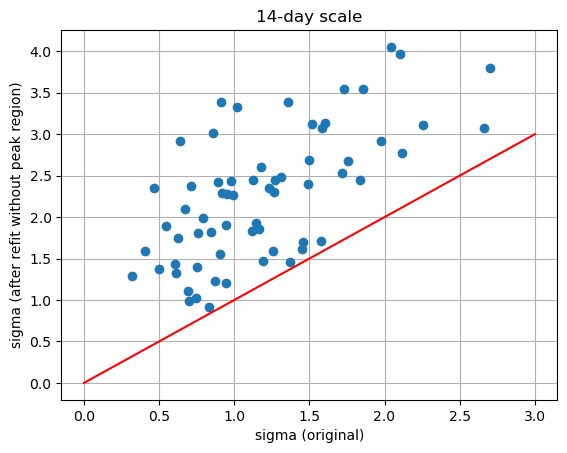

In [43]:
plt.plot(table_14d['sigma'],table_14d['sigma2'], 'o')
plt.plot([0,3.0],[0,3.0],'r-')
plt.xlabel('sigma (original)')
plt.ylabel('sigma (after refit without peak region)')
plt.title('14-day scale')
plt.grid()

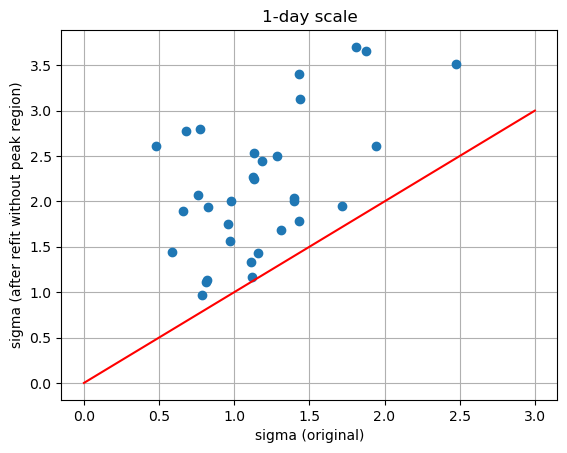

In [44]:
plt.plot(table_1d['sigma'],table_1d['sigma2'], 'o')
plt.plot([0,3.0],[0,3.0],'r-')
plt.xlabel('sigma (original)')
plt.ylabel('sigma (after refit without peak region)')
plt.title('1-day scale')
plt.grid()